In [91]:
# ============================================================
# Step 1
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [92]:
# ============================================================
# Step 2(خواندن دیتاست)
# ============================================================

df = pd.read_csv("dataset.csv")

df.head()

,a1,a2,a3,a4,a5,a6,a7,a8,b
0,577,577,577,577,8.406420e+12,14569190915,76332,561,577
1,561,561,558,561,7.007520e+12,12491198051,65308,545,561
2,545,545,545,545,3.171030e+12,5818400805,30226,530,545
3,522,543,513,530,3.355910e+12,6331782738,39889,528,543
4,528,528,525,528,2.299840e+12,4357376948,25849,513,528


In [93]:
# ============================================================
# Step 3(بررسی ابعاد و اطلاعات دیتاست)
# ============================================================

print("Shape :", df.shape)
print()

print(df.dtypes)

Shape : (19, 9)

a1      int64
a2      int64
a3      int64
a4      int64
a5    float64
a6      int64
a7      int64
a8      int64
b       int64
dtype: object


In [94]:
# ============================================================
# Step 4(تشکیل ماتریس A و بردار b)
# ============================================================

A = df.iloc[:, :-1].values
b = df.iloc[:, -1].values

print("A Shape :", A.shape)
print("b Shape :", b.shape)

A Shape : (19, 8)
b Shape : (19,)


In [95]:
# ============================================================
# Step 5(بررسی رتبه ماتریس A)
# ============================================================

rank = np.linalg.matrix_rank(A)

print("Rank of A :", rank)

Rank of A : 8


In [96]:
# ============================================================
# Step 6(بررسی نوع دستگاه)
# ============================================================

m, n = A.shape

print("Number of Equations :", m)
print("Number of Unknowns :", n)

if m > n:
    print("System : Overdetermined")
elif m < n:
    print("System : Underdetermined")
else:
    print("System : Square")

Number of Equations : 19
Number of Unknowns : 8
System : Overdetermined


In [97]:
# ============================================================
# Step 7(حل دستگاه با روش Least Squares)
# ============================================================

x_ls, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

print("Solution Vector (x):")
print(x_ls)

Solution Vector (x):
[-3.34929260e-01  5.41441775e-01 -3.88681764e-01  1.24348048e+00
 -1.64673830e-11  1.83771029e-08 -1.70849672e-03 -6.45730062e-02]


In [98]:
# ============================================================
# Step 8(پیش‌بینی مقادیر با روش Least Squares)
# ============================================================

y_pred_ls = A @ x_ls

print(y_pred_ls[:5])

[575.04593294 563.947368   547.25668894 537.67271267 526.45310829]


In [99]:
# ============================================================
# Step 9(محاسبه خطای روش Least Squares)
# ============================================================

mse_ls = mean_squared_error(b, y_pred_ls)
r2_ls = r2_score(b, y_pred_ls)

print("MSE :", mse_ls)
print("R² :", r2_ls)

MSE : 7.3696542243521606
R² : 0.9861018201741102


In [100]:
# ============================================================
# Step 10(آموزش مدل Linear Regression)
# ============================================================

model = LinearRegression()

model.fit(A, b)

print("Coefficients:")
print(model.coef_)

Coefficients:
[-3.32885174e-01  5.36113097e-01 -3.91291958e-01  1.24188632e+00
 -1.52939883e-11  1.76063606e-08 -1.68222033e-03 -6.65379619e-02]


In [101]:
# ============================================================
# Step 11(پیش‌بینی با مدل Linear Regression)
# ============================================================

y_pred_lr = model.predict(A)

print(y_pred_lr[:5])

[575.17415103 563.90514332 547.0753929  537.64158934 526.42917056]


In [102]:
# ============================================================
# Step 12(ارزیابی مدل Linear Regression)
# ============================================================

mse_lr = mean_squared_error(b, y_pred_lr)
r2_lr = r2_score(b, y_pred_lr)

print("MSE :", mse_lr)
print("R² :", r2_lr)

MSE : 7.358189844178921
R² : 0.9861234404581004


In [103]:
# ============================================================
# Step 13(جدول مقایسه دو روش)
# ============================================================

comparison = pd.DataFrame({
    "Method": ["Least Squares", "Linear Regression"],
    "MSE": [mse_ls, mse_lr],
    "R2 Score": [r2_ls, r2_lr]
})

comparison

,Method,MSE,R2 Score
0,Least Squares,7.369654,0.986102
1,Linear Regression,7.358190,0.986123


In [104]:
# ============================================================
# Step 14(مقایسه مقدار واقعی و پیش‌بینی‌شده)
# ============================================================

result = pd.DataFrame({
    "Actual": b,
    "Least Squares": y_pred_ls,
    "Linear Regression": y_pred_lr
})

result.head()

,Actual,Least Squares,Linear Regression
0,577,575.045933,575.174151
1,561,563.947368,563.905143
2,545,547.256689,547.075393
3,543,537.672713,537.641589
4,528,526.453108,526.429171


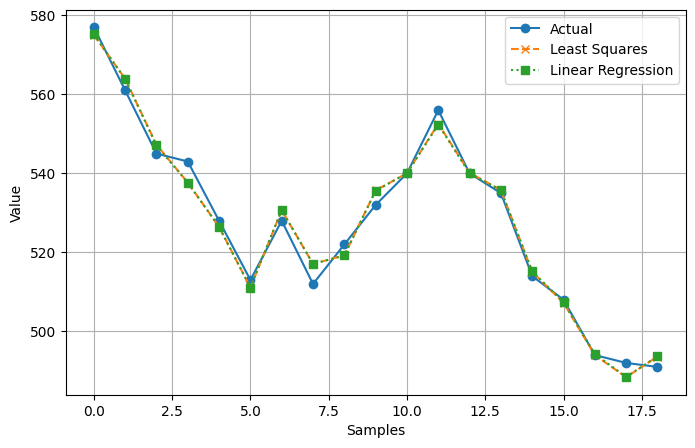

In [105]:
# ============================================================
# Step 15(نمودار مقایسه پیش‌بینی‌ها)
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(b, marker='o', label="Actual")

plt.plot(y_pred_ls, marker='x', linestyle='--', label="Least Squares")

plt.plot(y_pred_lr, marker='s', linestyle=':', label="Linear Regression")

plt.xlabel("Samples")
plt.ylabel("Value")

plt.legend()
plt.grid()

plt.show()

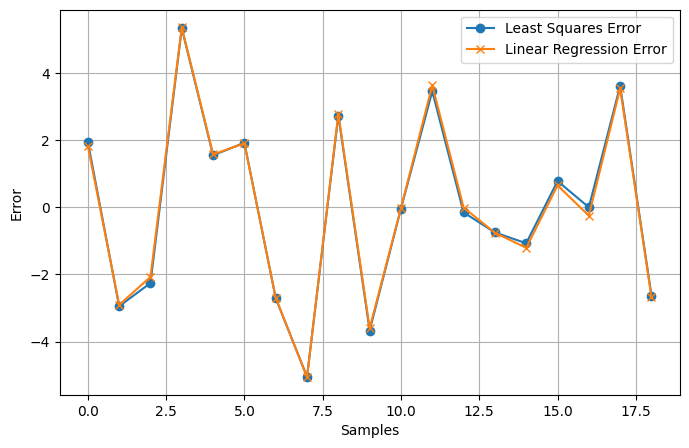

In [106]:
# ============================================================
# Step 16(نمودار خطای مدل‌ها)
# ============================================================

error_ls = b - y_pred_ls
error_lr = b - y_pred_lr

plt.figure(figsize=(8,5))

plt.plot(error_ls, marker='o', label="Least Squares Error")

plt.plot(error_lr, marker='x', label="Linear Regression Error")

plt.xlabel("Samples")
plt.ylabel("Error")

plt.legend()
plt.grid()

plt.show()

In [107]:
# ============================================================
# Step 17(حل دستی Least Squares با فرمول جبر خطی)
# ============================================================

x_manual = np.linalg.inv(A.T @ A) @ A.T @ b

print(x_manual)

[-3.34928212e-01  5.41441126e-01 -3.88682165e-01  1.24348042e+00
 -1.64673134e-11  1.83771028e-08 -1.70849672e-03 -6.45730062e-02]


In [108]:
# ============================================================
# Step 18(مقایسه جواب دستی و کتابخانه‌ای)
# ============================================================

difference = np.linalg.norm(x_manual - x_ls)

print("Difference :", difference)

Difference : 1.2970443605672864e-06
